<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Fseminario/seminario/urban_fire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instala dependências
!pip install datasets tensorflow scikit-learn pillow

In [ ]:
from datasets import load_dataset

# Carregar dataset do HuggingFace
dataset = load_dataset(
    path='incrisvel/urban-fire-identification'
)

In [4]:
# Separar deterministicamente amostras de treino e teste
split_dataset = dataset['train'].train_test_split(
    test_size=0.2,
    seed=1
)

train_data = split_dataset['train']
test_data = split_dataset['test']

# Mostrar estrutura do dataset
split_dataset
split_dataset['train']

Dataset({
    features: ['image', 'label'],
    num_rows: 643
})

In [ ]:
from tensorflow.keras.applications import MobileNetV2, InceptionV3, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Criar modelo pré-treinado para classificação
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

inception = InceptionV3(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(299, 299, 3)
)

resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

In [6]:
CLASS_NAMES = dataset['train'].features['label'].names

models = {
    'MobileNetV2': {
        'feature_extractor': mobilenet,
        'image_size': (224, 224),
        'preprocess': mobilenet_preprocess
    },
    'InceptionV3': {
        'feature_extractor': inception,
        'image_size': (299, 299),
        'preprocess': inception_preprocess
    },
    'ResNet50': {
        'feature_extractor': resnet,
        'image_size': (224, 224),
        'preprocess': resnet_preprocess
    }
}

In [7]:
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model
import numpy as np

# Preparar imagens
def preprocess_images(model_name, dataset):
    images = []
    labels = []

    for sample in dataset:
        image = sample['image']

        # Converter para RGB por garantia
        image = image.convert('RGB')

        # Redimensionar imagens para mesmo tamanho
        image = image.resize(models[model_name]['image_size'])

        # Converter imagem para um ndarray
        image = img_to_array(image)

        images.append(image)
        labels.append(sample['label'])

    images = np.array(images)
    labels = np.array(labels)

    # Preprocessamento
    images = models[model_name]['preprocess'](images)

    return images, labels


# Extração de features
def extract_features(model_name, dataset):

    # Extrair embeddings
    features = models[model_name]['feature_extractor'].predict(
        dataset,
        verbose=0,
        batch_size=32,
    )

    return features

In [8]:
for model_name, data in models.items():
    train_images, train_labels = preprocess_images(
        model_name,
        train_data
    )

    test_images, test_labels = preprocess_images(
        model_name,
        test_data
    )

    data['train_images'] = train_images
    data['train_labels'] = train_labels

    data['test_images'] = test_images
    data['test_labels'] = test_labels

In [9]:
import time

for model_name, data in models.items():
    start = time.perf_counter()

    X_train = extract_features(
        model_name,
        data['train_images'],
    )

    X_test = extract_features(
        model_name,
        data['test_images']
    )

    end = time.perf_counter()

    data['embeddings'] = {
        'X_train': X_train,
        'X_test': X_test
    }

    data['feature_extraction_time'] = end - start

In [10]:
from sklearn.preprocessing import StandardScaler

# Normalização dos embeddings para SVM
for model_name, data in models.items():
    embeddings = data['embeddings']
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(embeddings['X_train'])

    X_test_scaled = scaler.transform(embeddings['X_test'])

    embeddings['X_train'] = X_train_scaled
    embeddings['X_test'] = X_test_scaled

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['poly', 'sigmoid', 'rbf']
}

for model_name, data in models.items():
    embeddings = data['embeddings']
    X_train, y_train = embeddings['X_train'], data['train_labels']

    grid = GridSearchCV(
        SVC(),
        param_grid,
        cv=5,
        scoring='accuracy'
    )

    grid.fit(X_train, y_train)

    data['best_params_svm'] = grid.best_params_

In [12]:
for model_name, data in models.items():
    print(f'Melhores parâmetros para SVM com {model_name}:', data['best_params_svm'])

Melhores parâmetros para SVM com MobileNetV2: {'C': 1, 'kernel': 'rbf'}
Melhores parâmetros para SVM com InceptionV3: {'C': 1, 'kernel': 'sigmoid'}
Melhores parâmetros para SVM com ResNet50: {'C': 1, 'kernel': 'sigmoid'}


In [13]:
# Treinar modelo com o melhor SVM
for model_name, data in models.items():
    best_params = data['best_params_svm']
    embeddings = data['embeddings']
    X_train, y_train = embeddings['X_train'], data['train_labels']

    svm = SVC(
        kernel=best_params['kernel'],
        C=best_params['C'],
        gamma='scale'
    )

    svm.fit(X_train, y_train)

    data['model_svm'] = svm

In [15]:
# Predições dos modelos
for model_name, data in models.items():
    svm = data['model_svm']

    y_pred = svm.predict(data['embeddings']['X_test'])

    data['predictions_svm'] = y_pred

============================ MobileNetV2 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.96      1.00      0.98        71
                 urban_fire       1.00      0.97      0.98        90

                   accuracy                           0.98       161
                  macro avg       0.98      0.98      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


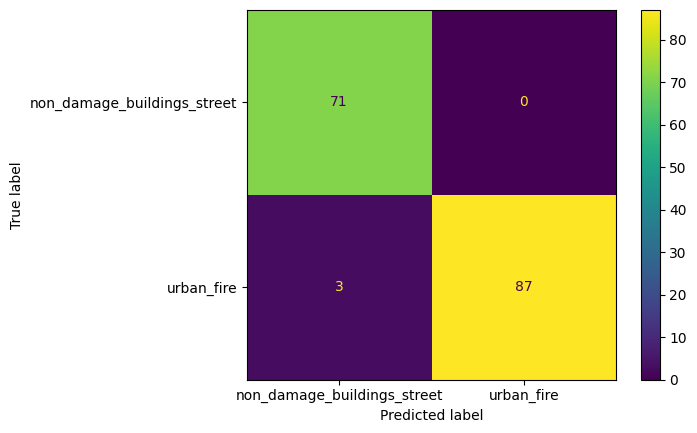

Tempo para extrair embeddings: 52.06s

============================ InceptionV3 ============================

Acurácia: 1.00

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      1.00      1.00        71
                 urban_fire       1.00      1.00      1.00        90

                   accuracy                           1.00       161
                  macro avg       1.00      1.00      1.00       161
               weighted avg       1.00      1.00      1.00       161


Matriz de confusão:


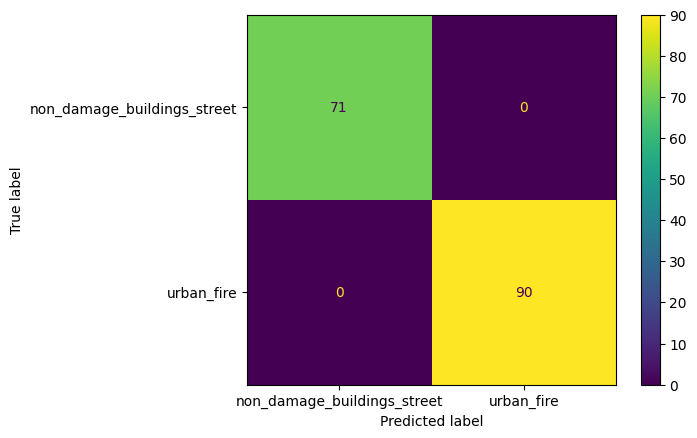

Tempo para extrair embeddings: 244.80s

============================ ResNet50 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.96      1.00      0.98        71
                 urban_fire       1.00      0.97      0.98        90

                   accuracy                           0.98       161
                  macro avg       0.98      0.98      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


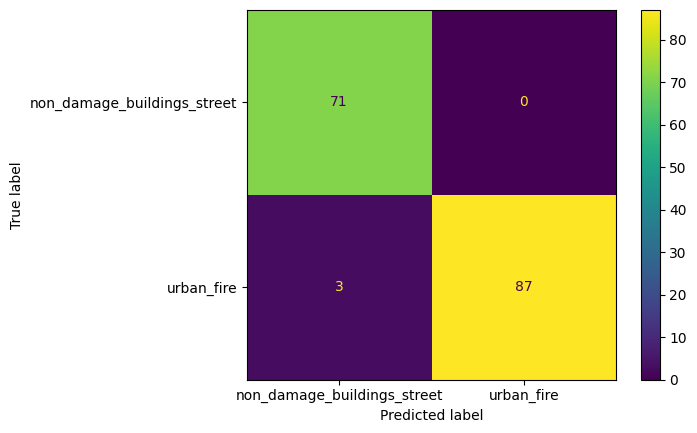

Tempo para extrair embeddings: 145.94s



In [25]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Métricas de análise (CNN + SVM)
for model_name, data in models.items():
    print(f'{'=' * 28} {model_name} {'=' * 28}')

    y_test = data['test_labels']
    y_pred_svm = data['predictions_svm']

    print(f'\nAcurácia: {accuracy_score(y_test, y_pred_svm):.2f}')

    print('\nRelatório da classificação:')
    print(classification_report(
        y_true=y_test,
        y_pred=y_pred_svm,
        target_names=CLASS_NAMES
    ))

    print(f'\nMatriz de confusão:')
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_test,
        y_pred=y_pred_svm,
        display_labels=CLASS_NAMES
    )

    disp.ax_.grid(False)
    plt.show()

    print(f'Tempo para extrair embeddings: {data['feature_extraction_time']:.2f}s\n')

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_classifier(feature_extractor):

    feature_extractor.trainable = False

    classifier = Sequential([
        feature_extractor,
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    classifier.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return classifier

In [20]:
for model_name, data in models.items():
    start = time.perf_counter()

    cnn = create_classifier(
        data['feature_extractor']
    )

    history = cnn.fit(
        data['train_images'],
        data['train_labels'],
        validation_split=0.2,
        epochs=1,
        batch_size=32,
        verbose=1
    )

    end = time.perf_counter()

    data['model_cnn'] = cnn
    data['cnn_history'] = history
    data['cnn_training_time'] = end - start

17/17 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8930 - loss: 0.2556 - val_accuracy: 0.9922 - val_loss: 0.0582
17/17 ━━━━━━━━━━━━━━━━━━━━ 158s 9s/step - accuracy: 0.9105 - loss: 0.2238 - val_accuracy: 0.9767 - val_loss: 0.0942
17/17 ━━━━━━━━━━━━━━━━━━━━ 114s 6s/step - accuracy: 0.9086 - loss: 0.2084 - val_accuracy: 0.9690 - val_loss: 0.0879


In [ ]:
for model_name, data in models.items():

    y_prob = data['model_cnn'].predict(
        data['test_images'],
        verbose=0
    )

    y_pred = (
        y_prob > 0.5
    ).astype(int).flatten()

    data['predictions_cnn'] = y_pred

============================ MobileNetV2 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.96      1.00      0.98        71
                 urban_fire       1.00      0.97      0.98        90

                   accuracy                           0.98       161
                  macro avg       0.98      0.98      0.98       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


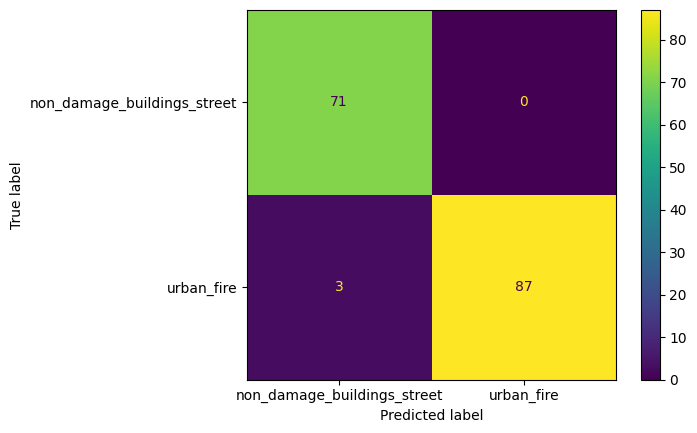

============================ InceptionV3 ============================

Acurácia: 0.98

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       1.00      0.94      0.97        71
                 urban_fire       0.96      1.00      0.98        90

                   accuracy                           0.98       161
                  macro avg       0.98      0.97      0.97       161
               weighted avg       0.98      0.98      0.98       161


Matriz de confusão:


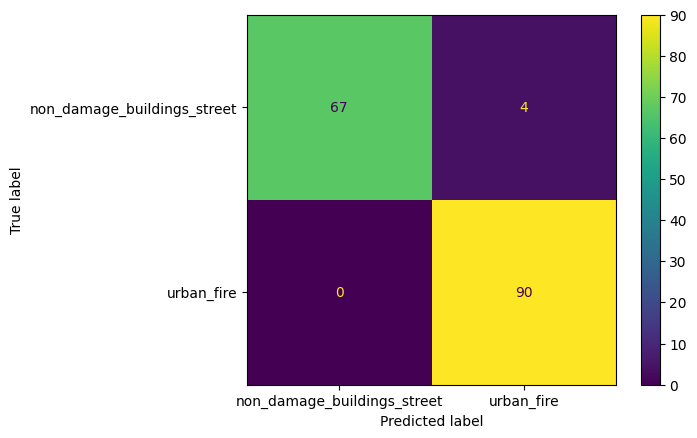

============================ ResNet50 ============================

Acurácia: 0.96

Relatório da classificação:
                             precision    recall  f1-score   support

non_damage_buildings_street       0.92      1.00      0.96        71
                 urban_fire       1.00      0.93      0.97        90

                   accuracy                           0.96       161
                  macro avg       0.96      0.97      0.96       161
               weighted avg       0.97      0.96      0.96       161


Matriz de confusão:


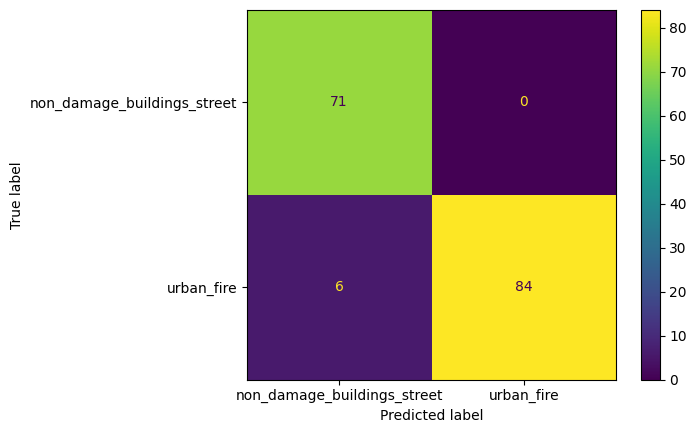

In [24]:
# Métricas de análise (CNN pura)
for model_name, data in models.items():
    print(f'{'=' * 28} {model_name} {'=' * 28}')

    y_test = data['test_labels']
    y_pred_cnn = data['predictions_cnn']

    print(f'\nAcurácia: {accuracy_score(y_test, y_pred_cnn):.2f}')

    print('\nRelatório da classificação:')
    print(classification_report(
        y_true=y_test,
        y_pred=y_pred_cnn,
        target_names=CLASS_NAMES
    ))

    print(f'\nMatriz de confusão:')
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_test,
        y_pred=y_pred_cnn,
        display_labels=CLASS_NAMES
    )
    disp.ax_.grid(False)
    plt.show()
